<a href="https://colab.research.google.com/github/Nikolai-N484/Data201_NikolaiN/blob/main/Project3/Nikolai_Navarro_Project3_Week14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data 201 Final Project**
## **Nikolai Navarro**
## Spring 2026
---

## **Introduction**
Write a short introduction describing:
- Your dataset
- Your prediction goal
- Why the topic is interesting or important
- Possible limitations or bias in the dataset

Include a citation for your dataset source.

The data set I will be using is titled "Employee Salaries - 2024" and has data collected from Montgomery County Maryland. The data is about the annual salary information including gross pay and overtime pay for all active, permanent employees of Montgomery County, MD paid in calendar year 2024.  It contains information such as department, base salary, overtime pay, longevity pay, and division. The data is realeased every year for the public to view.

This data set contains information from 2024 which is 2 years ago. So its contents may be outdated but not that much. I couldn't find the data set for 2025 salaries. The data may also be incorrect due to human error.

I want to predict the total annual salary an Montgomery County employee makes using variables from the data set such as the department, gender, and base pay, overtime pay, and longevity pay.. I chose this topic because it has data about the salaries in our county and being able to see what how much we are paying employees in the county can help us to create future budgets for county spending in the future.

**Citation:**\
“Employee Salaries - 2024: Open Data Portal.” Employee Salaries - 2024 | Open Data Portal, Montgomery County, 28 Feb. 2025, data.montgomerycountymd.gov/Human-Resources/Employee-Salaries-2024/2nq6-auk8/about_data.

---

## **Dataset and Preparation**

Include:
- Dataset size
- Explanation of variables
- Missing value handling
- Encoding categorical variables if needed
- Train/test split

Include at least one table describing variables.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.model_selection import train_test_split
import calendar
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

df = pd.read_csv("https://raw.githubusercontent.com/Nikolai-N484/Data201_NikolaiN/refs/heads/main/Employee_Salaries_-_2024_20260512.csv")

df.head()

,Department,Department Name,Division,Gender,Base Salary,2024 Overtime Pay,2024 Longevity Pay,Grade
0,ABS,Alcohol Beverage Services,ABS 85 IT Administration,M,"$169,555",$0,$0,M3
1,CUS,Community Use of Public Facilities,CUS 70 Finance and Administrative Support Team,F,"$141,876.93",$0,$0,M3
2,DGS,Department of General Services,DGS 36 Fleet Management Services,F,"$87,523",$748.37,"$2,701.48",16
3,CEX,Offices of the County Executive,CEX 15 Chief Administrative Officer's Office,F,"$207,000",$0,$0,EX2
4,HHS,Department of Health and Human Services,HHS 60 Office of Eligibility and Support Services,F,"$91,392",$0,"$5,733.27",N17


| Column | Description | API Field Name | Data Type |
|:-----|:------:|:------:|------:|
|  Department  |  Department code for the department to which the employee is assigned.  |  department  |  Text  |
|  Department Name  |  Name of the County Department to which the employee is assigned.  |  department_name  |  Text  |
|  Division  |  Name of the division within the County department to which the employee is assigned.  |  division  |  Text  |
|  Gender  |  Gender  |  gender  |  Text  |
|  Base Salary  |  Annual base salary for the employee at the end of the calendar year.  |  base_salary  |  Number  |
|  2024 Overtime Pay  |  Overtime pay the employee received for hours worked beyond the employee’s normally scheduled workday or workweek.  |  _2024_overtime_pay  |  Number  |
|  2024 Longevity Pay  |  Longevity pay the employee received for the length of service in County employment at the end of the calendar year.  |  _2024_longevity_pay  |  Number  |
|  Grade  |  Assigned grade for the employee at the end of the calendar year.  |  grade  |  Text  |

In [68]:
shape = df.shape
print(shape)

(10398, 8)


In [69]:
# Function to clean and convert currency columns to numeric
def clean_currency(col):
    return pd.to_numeric(col.astype(str).str.replace('$', '', regex = False).str.replace(',', '', regex = False))

# Clean Base Salary, 2024 Overtime Pay, and 2024 Longevity Pay columns
df["Base Salary"] = clean_currency(df["Base Salary"])
df["2024 Overtime Pay"] = clean_currency(df["2024 Overtime Pay"])
df["2024 Longevity Pay"] = clean_currency(df["2024 Longevity Pay"])

# Combining base salary and overtime/lengevity pay to get total annual salary
df["Total Salary"] = df["Base Salary"] + df["2024 Overtime Pay"] + df["2024 Longevity Pay"]
df.head()

,Department,Department Name,Division,Gender,Base Salary,2024 Overtime Pay,2024 Longevity Pay,Grade,Total Salary
0,ABS,Alcohol Beverage Services,ABS 85 IT Administration,M,169555.00,0.00,0.00,M3,169555.00
1,CUS,Community Use of Public Facilities,CUS 70 Finance and Administrative Support Team,F,141876.93,0.00,0.00,M3,141876.93
2,DGS,Department of General Services,DGS 36 Fleet Management Services,F,87523.00,748.37,2701.48,16,90972.85
3,CEX,Offices of the County Executive,CEX 15 Chief Administrative Officer's Office,F,207000.00,0.00,0.00,EX2,207000.00
4,HHS,Department of Health and Human Services,HHS 60 Office of Eligibility and Support Services,F,91392.00,0.00,5733.27,N17,97125.27


In [70]:
predictor_cols = ["Department", "Division", "Gender", "Base Salary", "2024 Overtime Pay", "2024 Longevity Pay"]

#Dropping rows with NA's if any
df = df.dropna(subset = ["Total Salary"] + predictor_cols)

shape2 = df.shape
print(shape2)

na = df.isna().sum()
print(na)

(10398, 9)
Department             0
Department Name        0
Division               0
Gender                 0
Base Salary            0
2024 Overtime Pay      0
2024 Longevity Pay     0
Grade                 22
Total Salary           0
dtype: int64


After cleaning the data set, removing any NA's for the variables I plan to use, and creating new variables to create a total annual salary there is a total of 10398 rows and 9 columns.

In [71]:
y = df["Total Salary"]

# Separate categorical and numerical predictor columns
categorical_cols = ["Department", "Division", "Gender"]
numerical_cols = ["Base Salary", "2024 Overtime Pay", "2024 Longevity Pay"]

# Create X by selecting the columns that will be used for modeling
X = df[categorical_cols + numerical_cols]

# Apply one-hot encoding to categorical features
X_encoded = pd.get_dummies(X, columns = categorical_cols, drop_first=True)

# Ensure all columns are numeric after encoding
X_encoded = X_encoded.apply(pd.to_numeric, errors='coerce')

# Split the preprocessed data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f"Features shape: {X_encoded.shape}")
print(f"Target rows: {len(y)}")

Features shape: (10398, 639)
Target rows: 10398


---
## **Exploratory Data Analysis**

Create:
- **2 meaningful visualizations**
- Short interpretations

Discuss:
- Interesting patterns
- Trends
- Possible relationships

Keep this section concise.

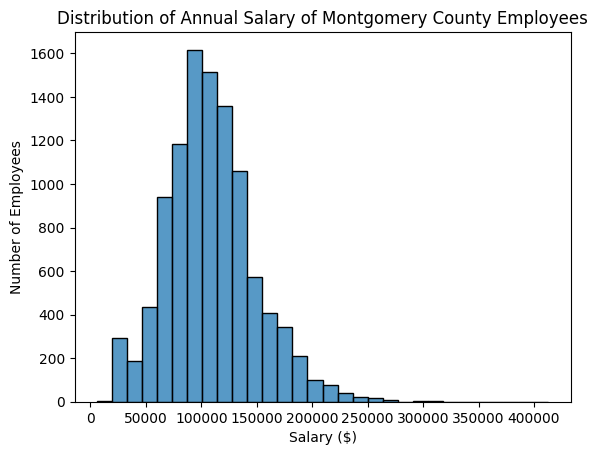

In [72]:
sns.histplot(df["Total Salary"], bins = 30)
plt.xlabel("Salary ($)")
plt.ylabel("Number of Employees")
plt.title("Distribution of Annual Salary of Montgomery County Employees")
plt.show()

The histogram looks roughly normal with a slight right skew. This histogram shows that the average annual salary for Montgomery County employees is between 90k to 120k dollars. A the highest annual salary earned by employee count is about 90k dollars with 1600 employees having that salary.  

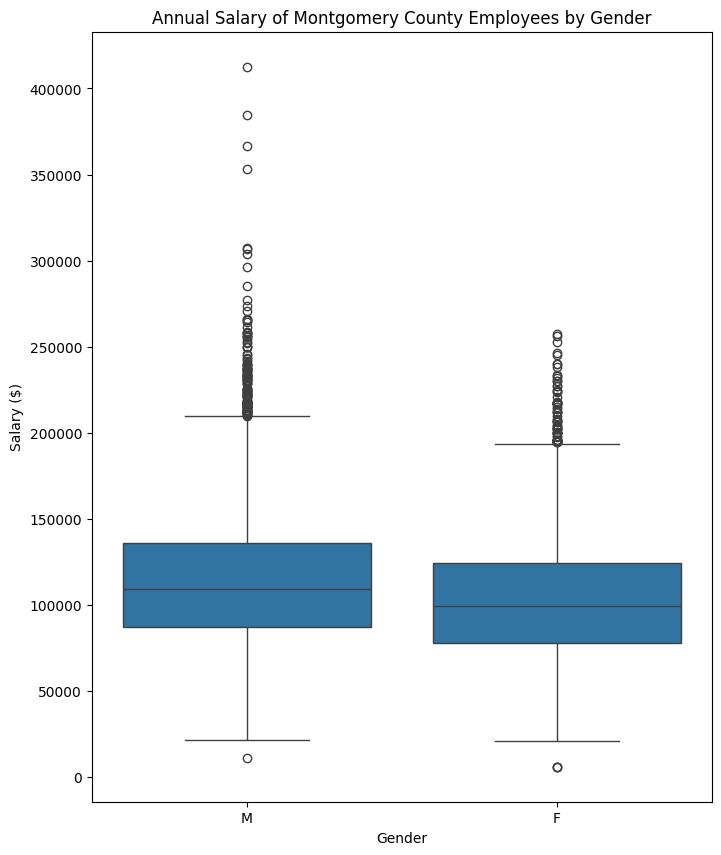

In [73]:
plt.figure(figsize = (8, 10))
sns.boxplot(x = "Gender", y = "Total Salary", data = df)
plt.xlabel("Gender")
plt.ylabel("Salary ($)")
plt.title("Annual Salary of Montgomery County Employees by Gender")
plt.show()

This boxplot shows the distribution of the annual salary of Montgomery County Employees by gender. Both box plots seem to be normally distributed with both having a significant amount of outliers.  It looks like men earn a higher median annual salary at 110k dollars while the womans median annual salary is around 110k dollars. The outlier amounts show that there are many more men that make high amounts of money a year compared to women.

---
## **Decision Tree Analysis (Core Section)**

This is the most important section of the project.

You must:
- Train a Decision Tree Regressor
- Try at least **two different tree depths**
- Briefly discuss possible overfitting
- Include a visualization or diagram of your tree

Also explain:
- The root node
- One important split
- One example prediction path

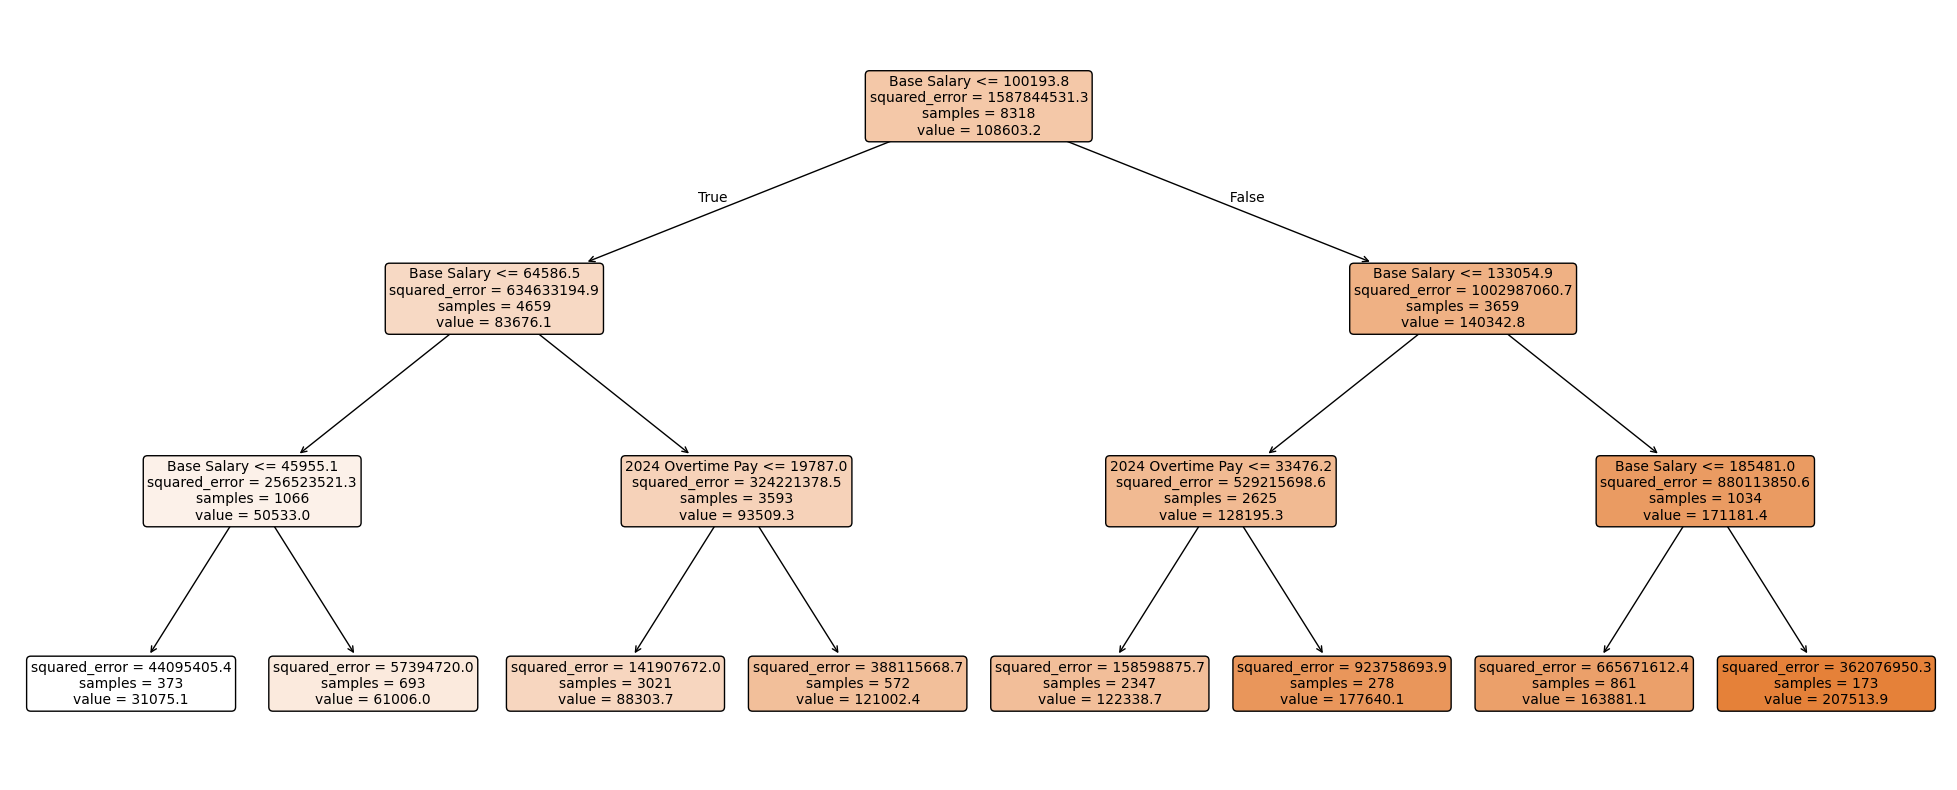

In [80]:
tree_small = DecisionTreeRegressor(max_depth = 3, random_state = 42)

tree_small.fit(X_train, y_train)

plt.figure(figsize = (25, 10))
plot_tree(tree_small, filled = True, feature_names = list(X_train.columns), max_depth = 3, rounded = True, fontsize = 10, precision = 1)
plt.show()

The root node for the decision tree is the base salary which would make sense as that is the baseline for what an employee would be paid for a year without any outside factors.

After the first initial split the data splits again on both branches by base salary with it being <=64586.5 on the left branch and <= 133054.9 on the right branch. This is to further seperate employee salaries into smaller groups which are then either split again by base salary or overtime pay.

In [83]:
tree_big = DecisionTreeRegressor(max_depth = 6, random_state = 42)

tree_big.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=6, random_state=42)

In [84]:
tree_small_train_r2 = tree_small.score(X_train, y_train)
tree_small_test_r2 = tree_small.score(X_test, y_test)
tree_big_train_r2 = tree_big.score(X_train, y_train)
tree_big_test_r2 = tree_big.score(X_test, y_test)

print(f"Small Tree Train R^2: {tree_small_train_r2:.3f}")
print(f"Small Tree Test R^2: {tree_small_test_r2:.3f}")
print(f"Big Tree Train R^2: {tree_big_train_r2:.3f}")
print(f"Big Tree Test R^2: {tree_big_test_r2:.3f}")

Small Tree Train R^2: 0.851
Small Tree Test R^2: 0.874
Big Tree Train R^2: 0.983
Big Tree Test R^2: 0.982


Looking at the small trees r-squared it is actually showing it is underfitting because the training r-square of 0.851 is less than the testing r-square of 0.874. This means that the small tree model performs better on the unseen data than the data is learned from. This could be becuase the model had too little splits and the depth was too small limiting the models ability to learn from the data. So the model is not overfitting and it is generalizing well but it is underfitting which could lead to issues.

Looking at the big trees r-squared it isn't showing any signs of overfitting or under fitting as it had a training r-square of 0.983 and a testing r-square of 0.982. This shows that the descision tree model performs identically on the data it learned from and the unknown data with only a 0.001 difference between the r-squares. An overfitting model will begin to memorize specific noise from the data set but this model is able to generalize well without overfitting. This decision tree model is able to captures 98.3% of the variance in the data.

---
## **Ensemble Models**

Train:
- Random Forest
- Gradient Boosting

Compare them to your single decision tree.

Discuss:
- Did performance improve?
- Which model generalized better?
- Which model was easier to explain?

You are NOT expected to perform advanced hyperparameter tuning.

In [85]:
rf_model = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf_model.fit(X_train, y_train)

gb_model = GradientBoostingRegressor(n_estimators = 100, random_state = 42)
gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

---
## **Model Evaluation**

You must include:

| Metric | Meaning |
|---|---|
| MSE | Lower is better |
| \(R^2\) | Higher is better |

Include:
- A comparison table
- Actual vs Predicted visualization
- Short interpretation of results

---
## **Feature Importance**

For at least one ensemble model:
- Display feature importance
- Identify the top 3 most important features

Important:
- Feature importance does NOT prove causation

---
## **Final Reflection: The Model Battle**

Answer the following questions:

1. Which model performed best?
2. Which model was easiest to explain?
3. Which model would you choose in a real-world setting and why?